In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bb = pd.read_csv("/Users/emiliahernandez/Desktop/desarrollo/topGlobal/chartsBillboard.csv")

bb["date"] = pd.to_datetime(bb["date"])

# only 2010 onward
bb = bb[bb["date"].dt.year >= 2010].copy()

bb = bb.sort_values(["date","rank"])


# Top 1 analysis

In [4]:
top1 = bb[bb["rank"] == 1].copy()

top1["song_id"] = (
    top1["song"].astype(str)
    + " — "
    + top1["artist"].astype(str)
)

top1 = top1.sort_values("date")

top1["weeks_as_no1"] = top1.groupby("song_id").cumcount() + 1

top1["year"] = top1["date"].dt.year


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_518/3583920243.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(songs), 20))


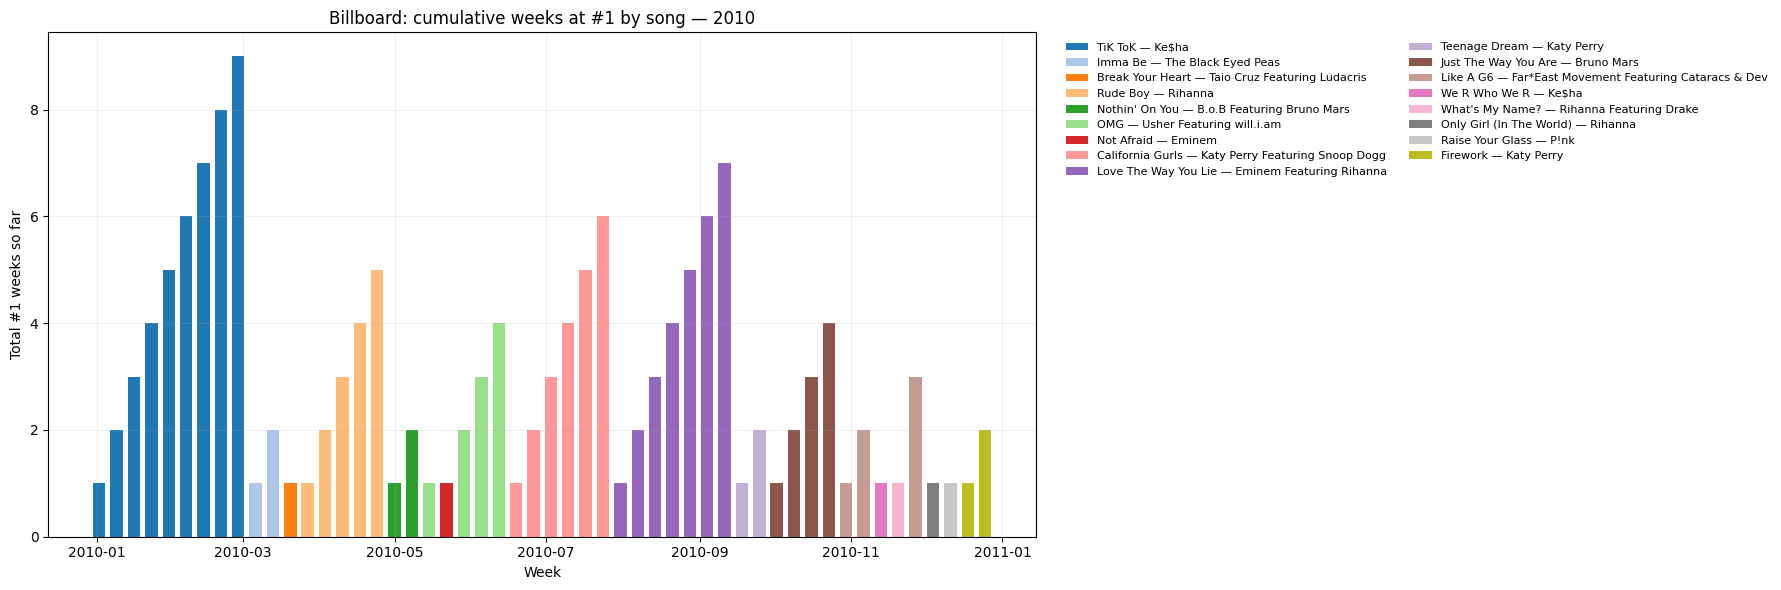

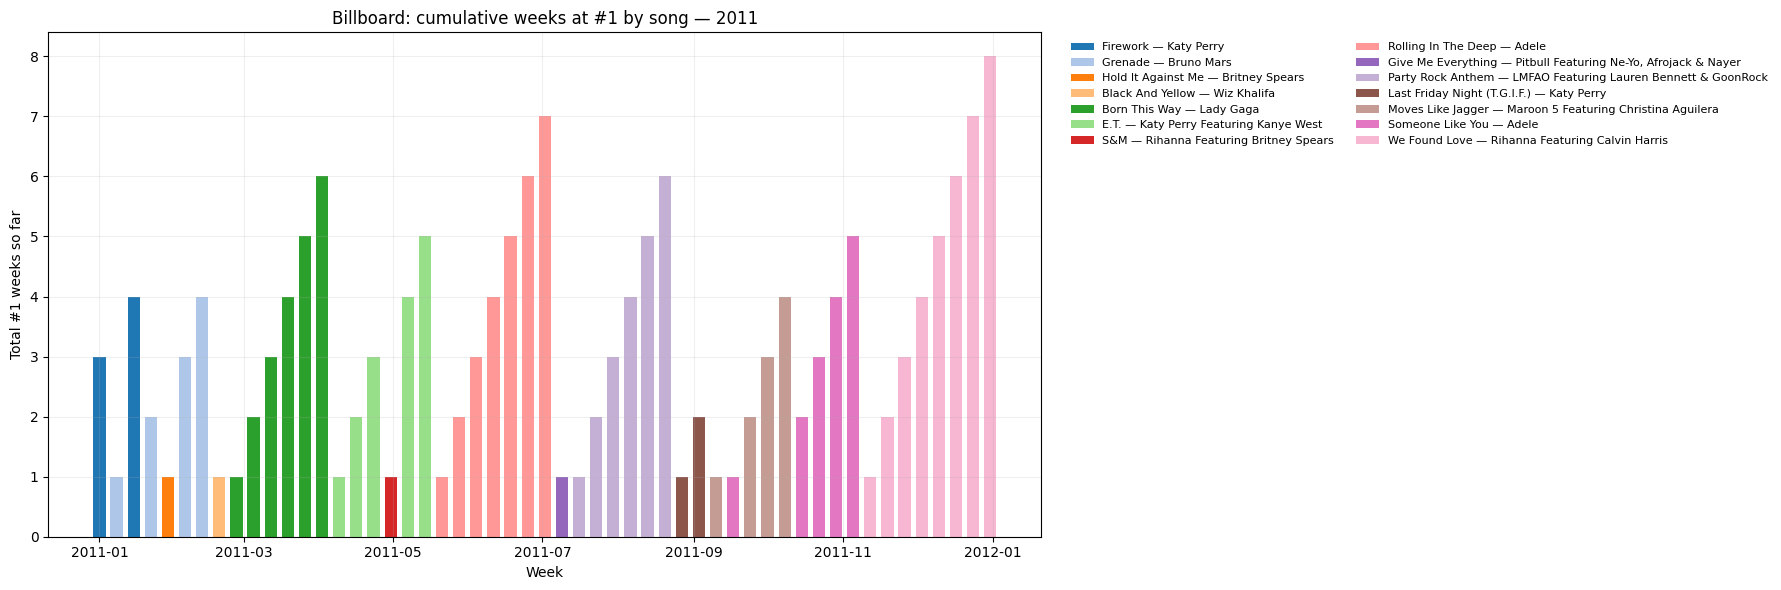

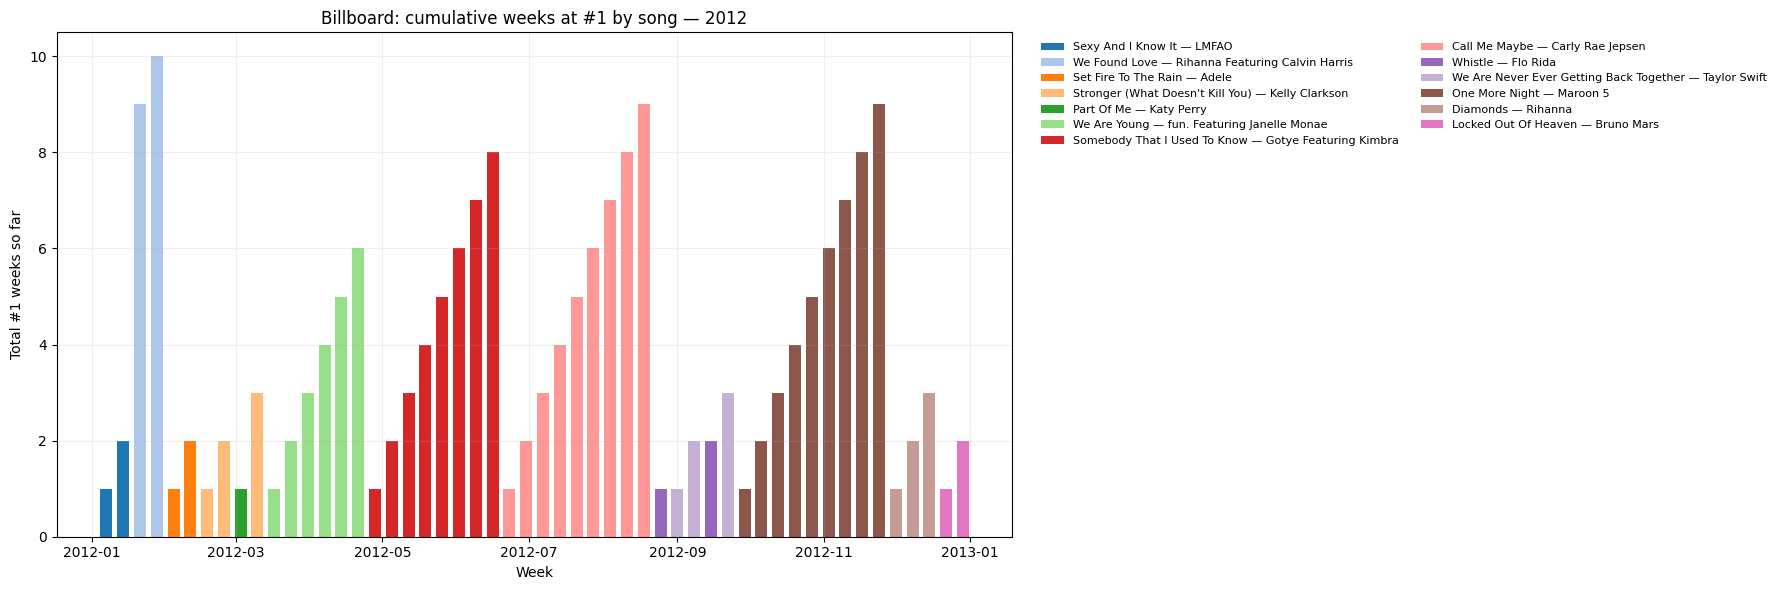

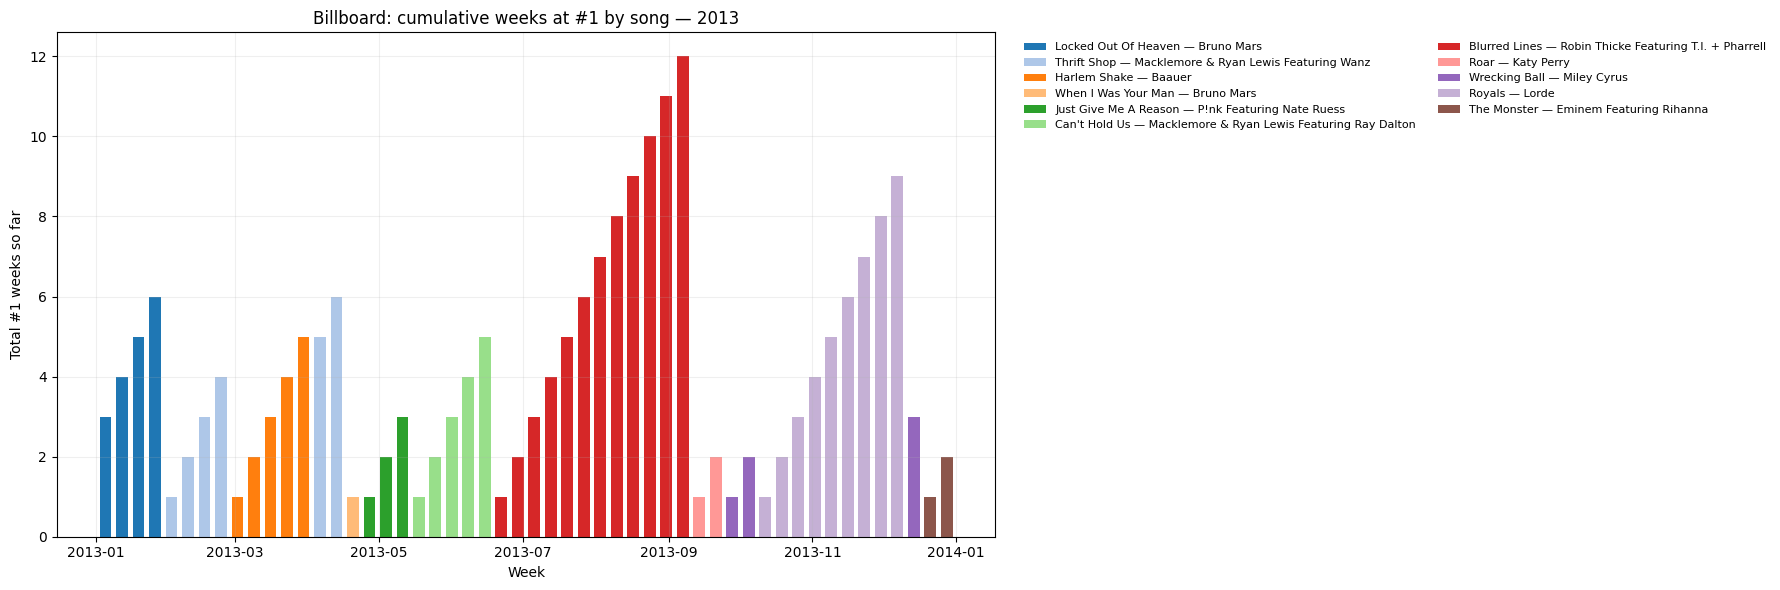

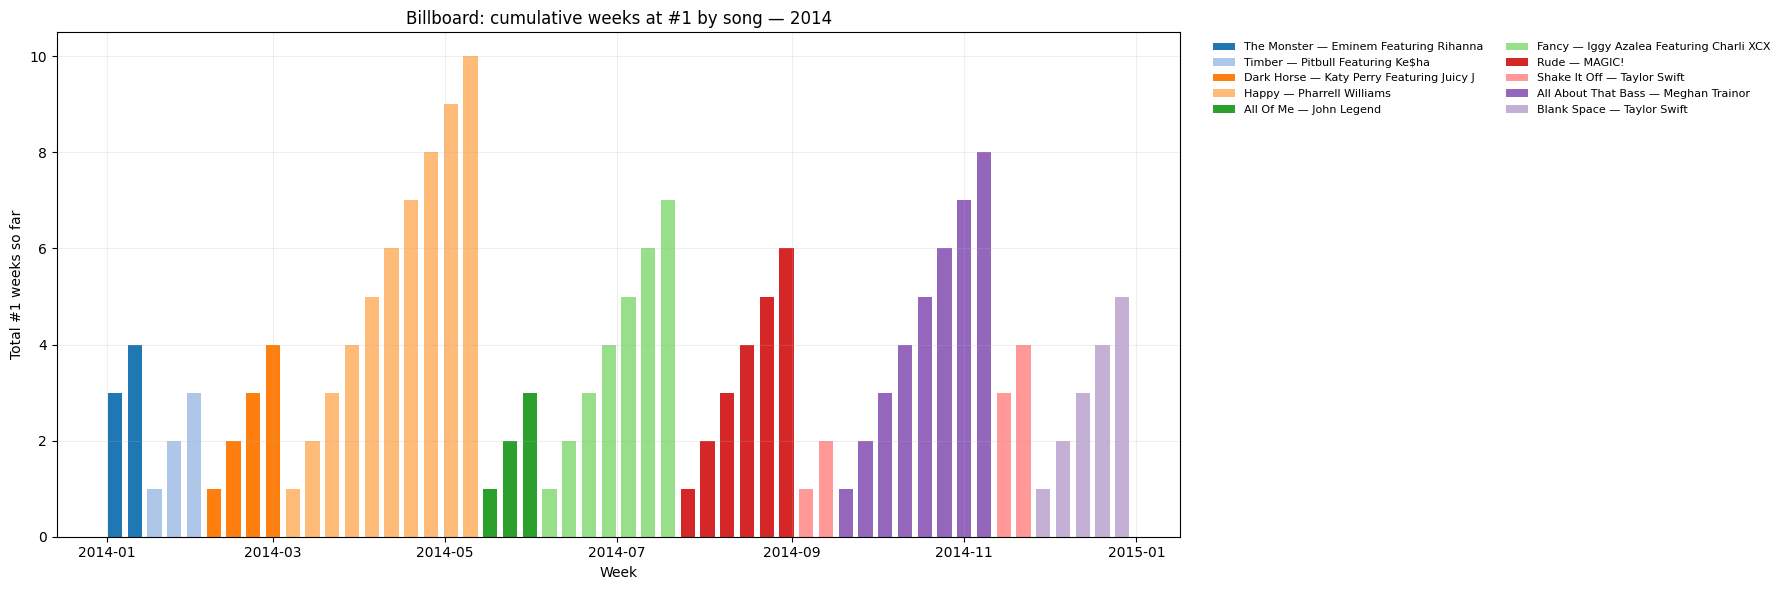

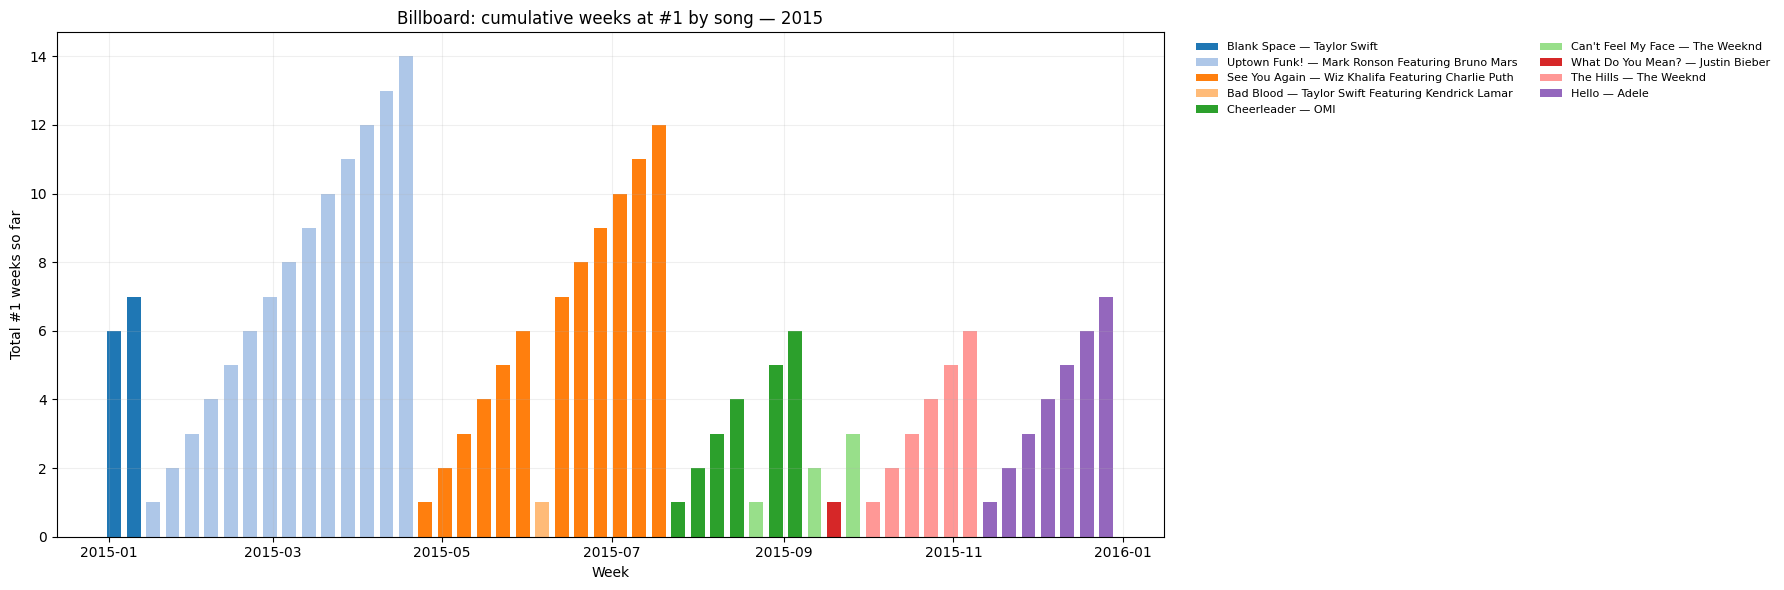

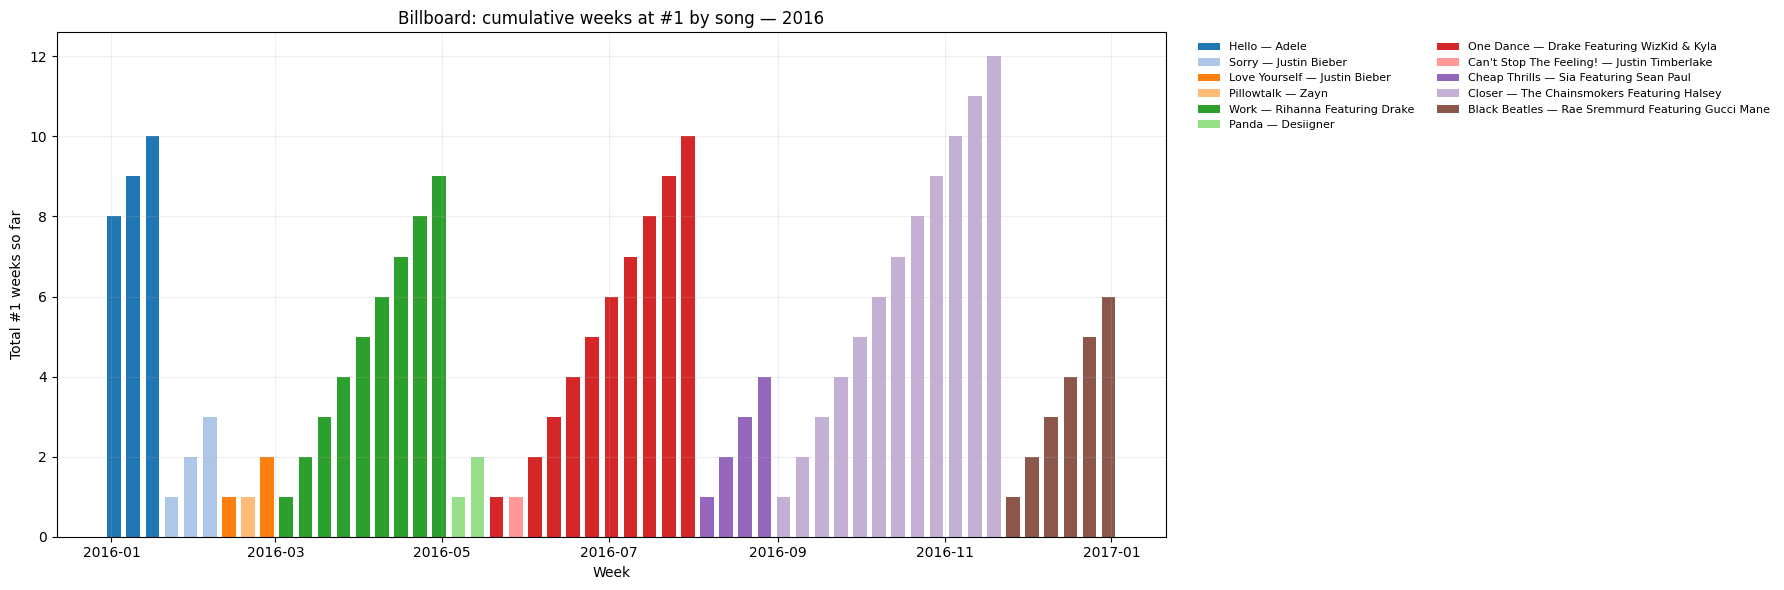

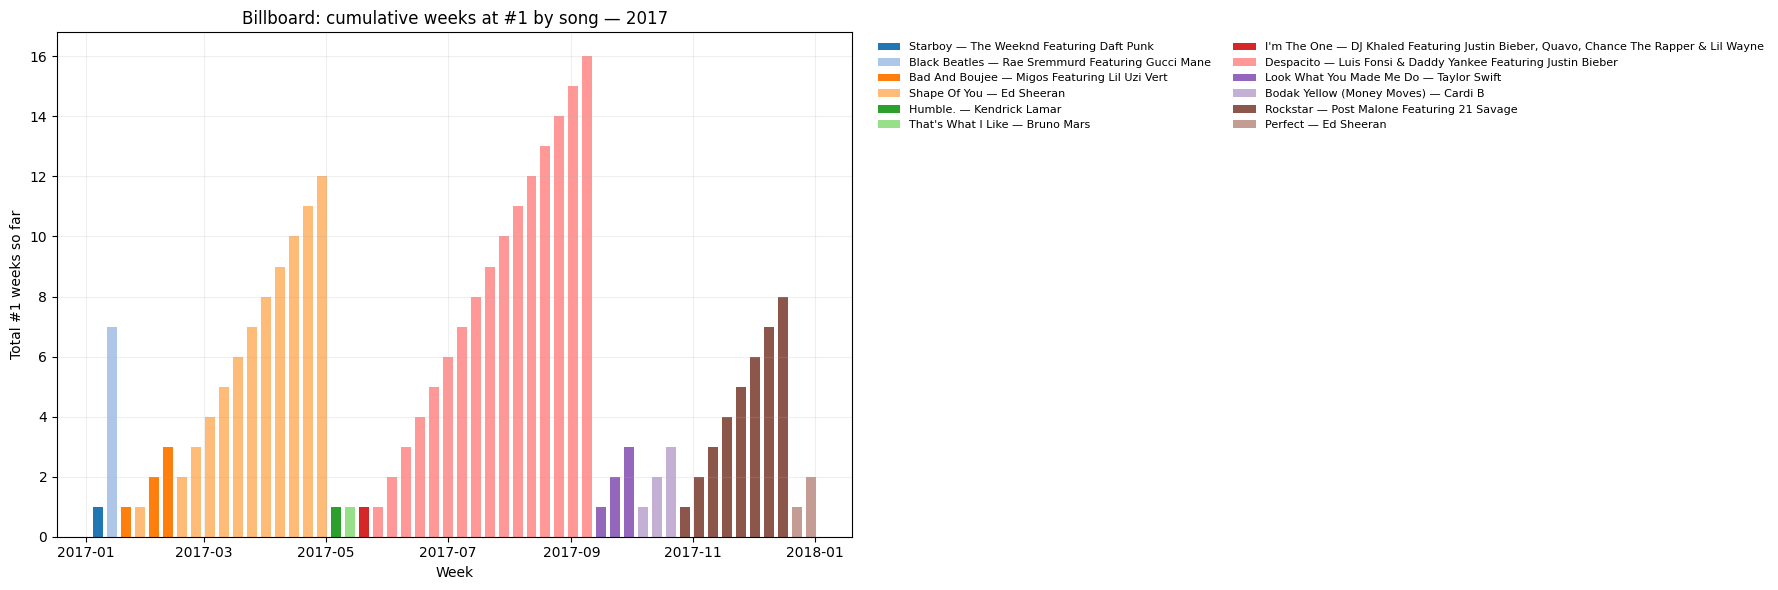

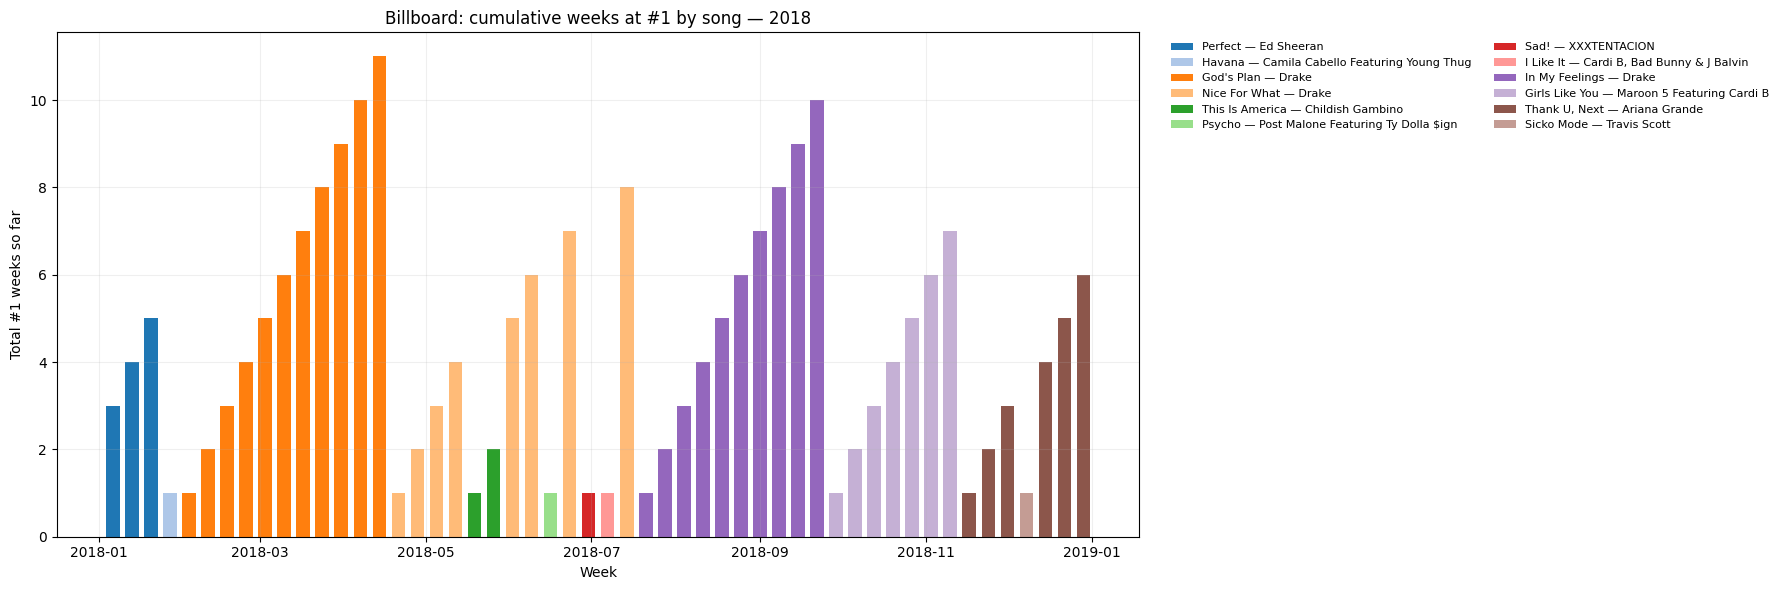

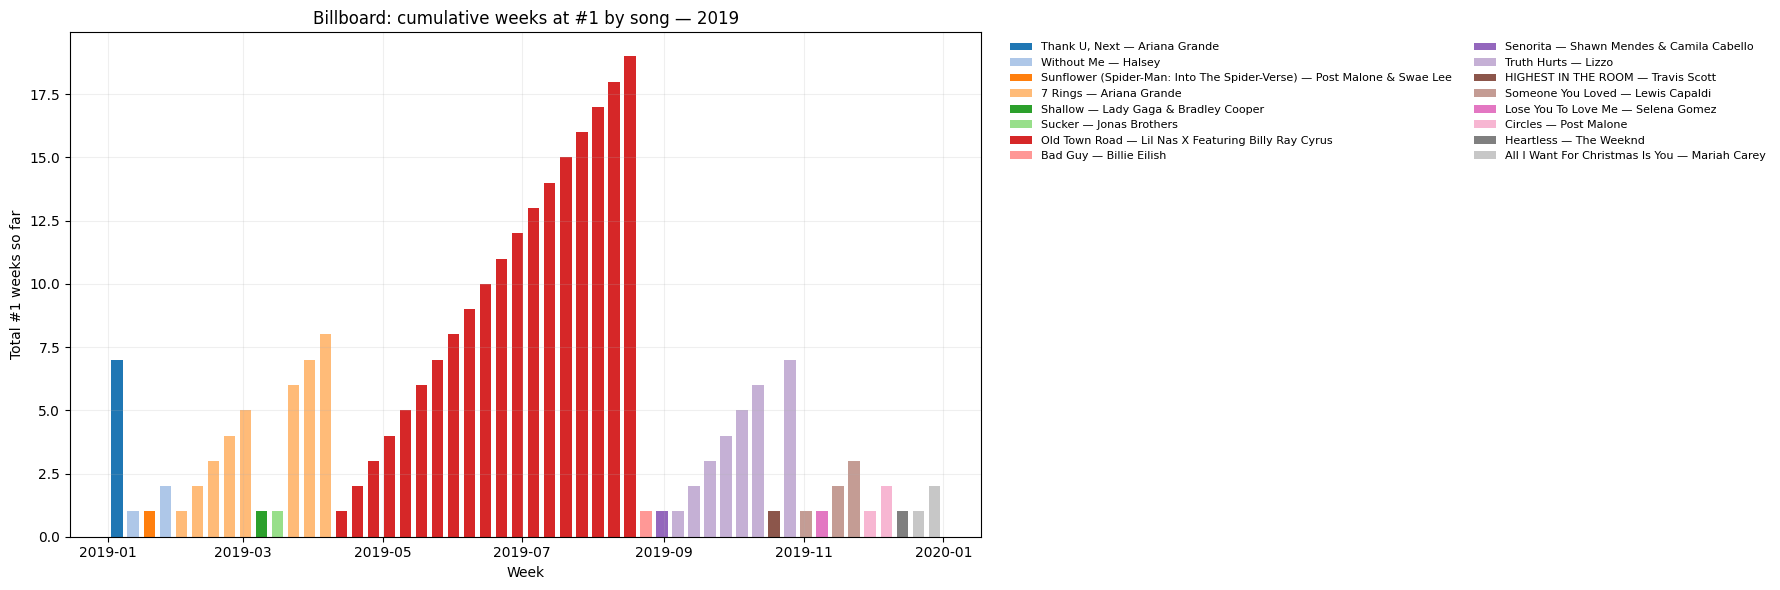

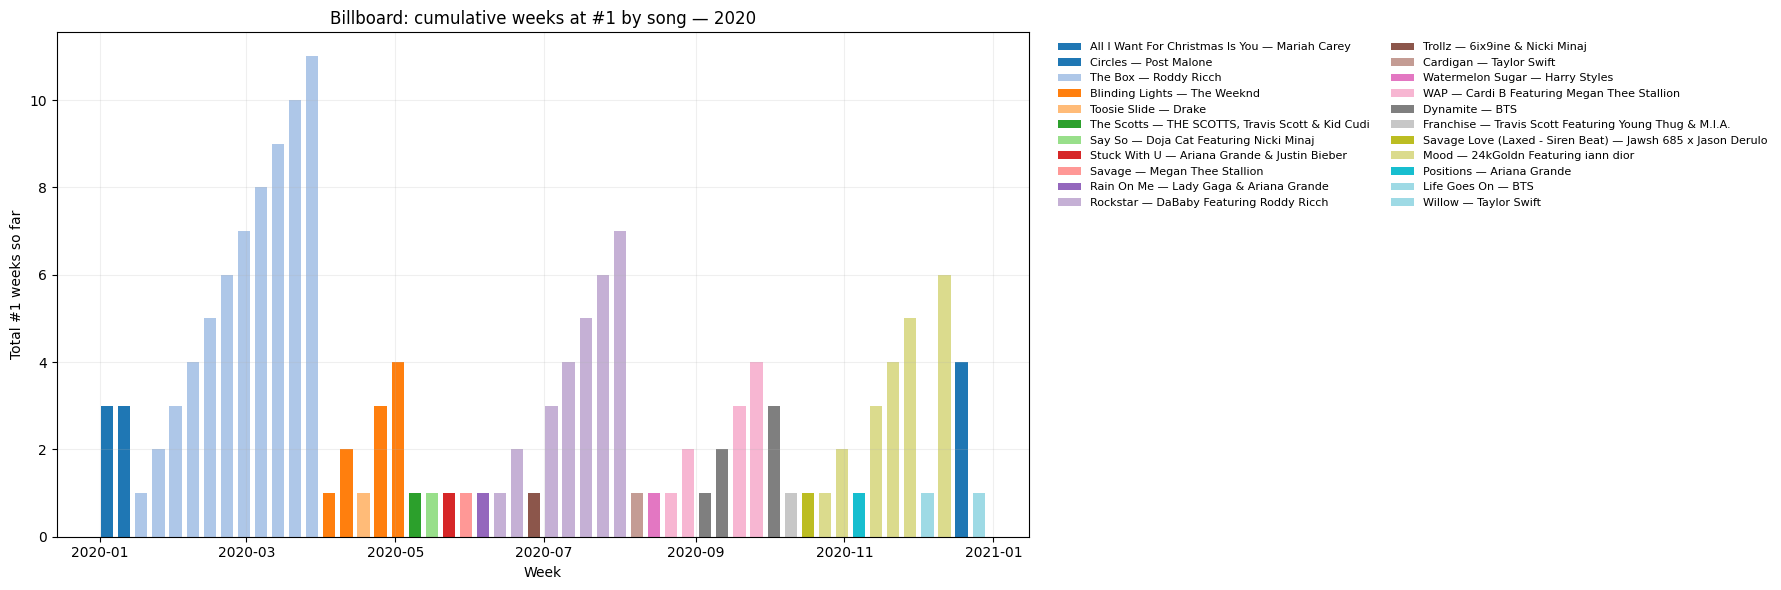

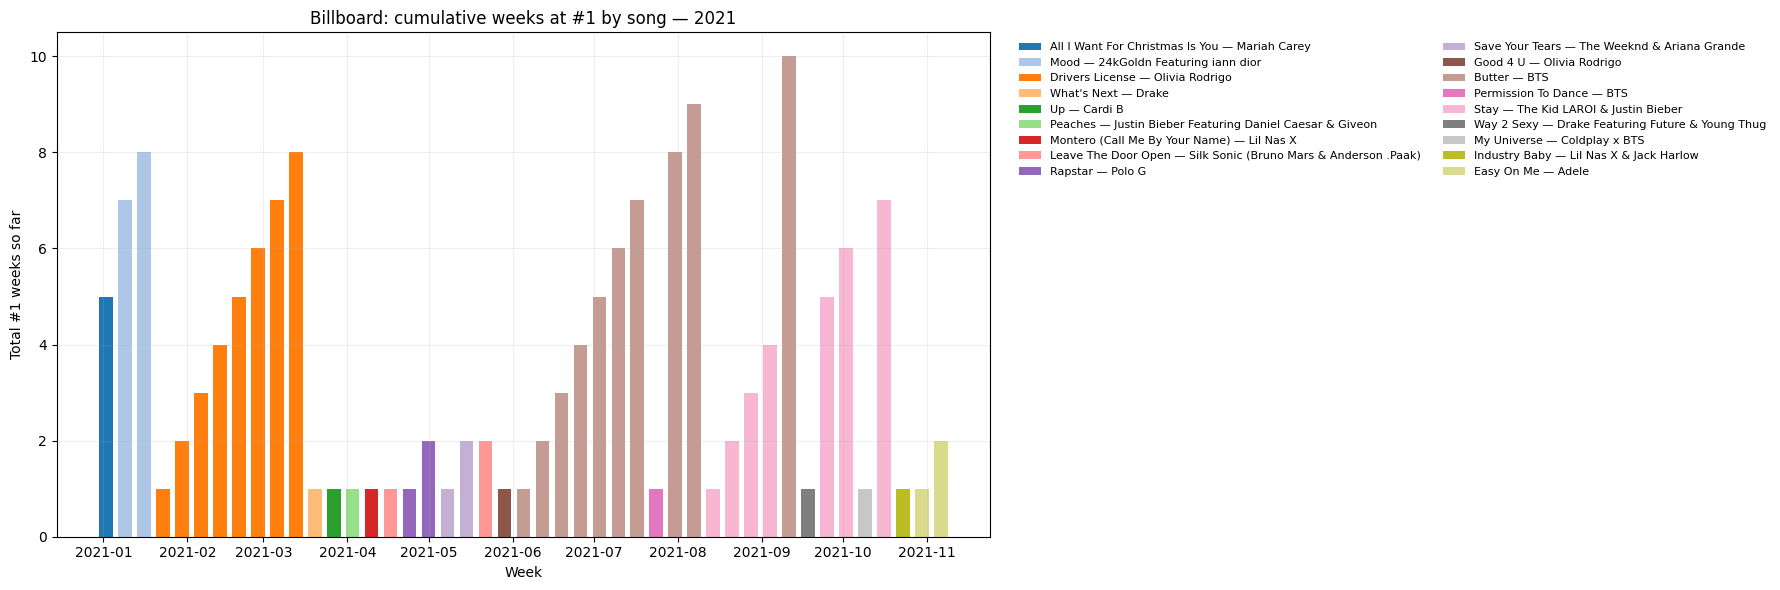

In [8]:
years = sorted(top1["year"].unique())

for y in years:
    dfy = top1[top1["year"] == y].copy()
    if dfy.empty:
        continue

    songs = dfy["song_id"].unique()

    cmap = plt.cm.get_cmap("tab20", max(len(songs), 20))
    color_map = {s: cmap(i % cmap.N) for i, s in enumerate(songs)}

    plt.figure(figsize=(18,6))

    for s in songs:
        sub = dfy[dfy["song_id"] == s]
        plt.bar(
            sub["date"],
            sub["weeks_as_no1"],
            width=5,
            color=color_map[s],
            label=s
        )

    plt.title(f"Billboard: cumulative weeks at #1 by song — {y}")
    plt.xlabel("Week")
    plt.ylabel("Total #1 weeks so far")
    plt.grid(alpha=0.2)

    # legend outside
    plt.legend(
        ncol=2,
        fontsize=8,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()


# Top 5 analysis

In [6]:
top5 = bb[bb["rank"] <= 5].copy()

top5["song_id"] = (
    top5["song"].astype(str)
    + " — "
    + top5["artist"].astype(str)
)

top5 = top5.sort_values(["date","rank"])

top5["top5_appearances"] = (
    top5.groupby("song_id").cumcount() + 1
)

top5["year"] = top5["date"].dt.year


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_518/3297472257.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(songs), 20))


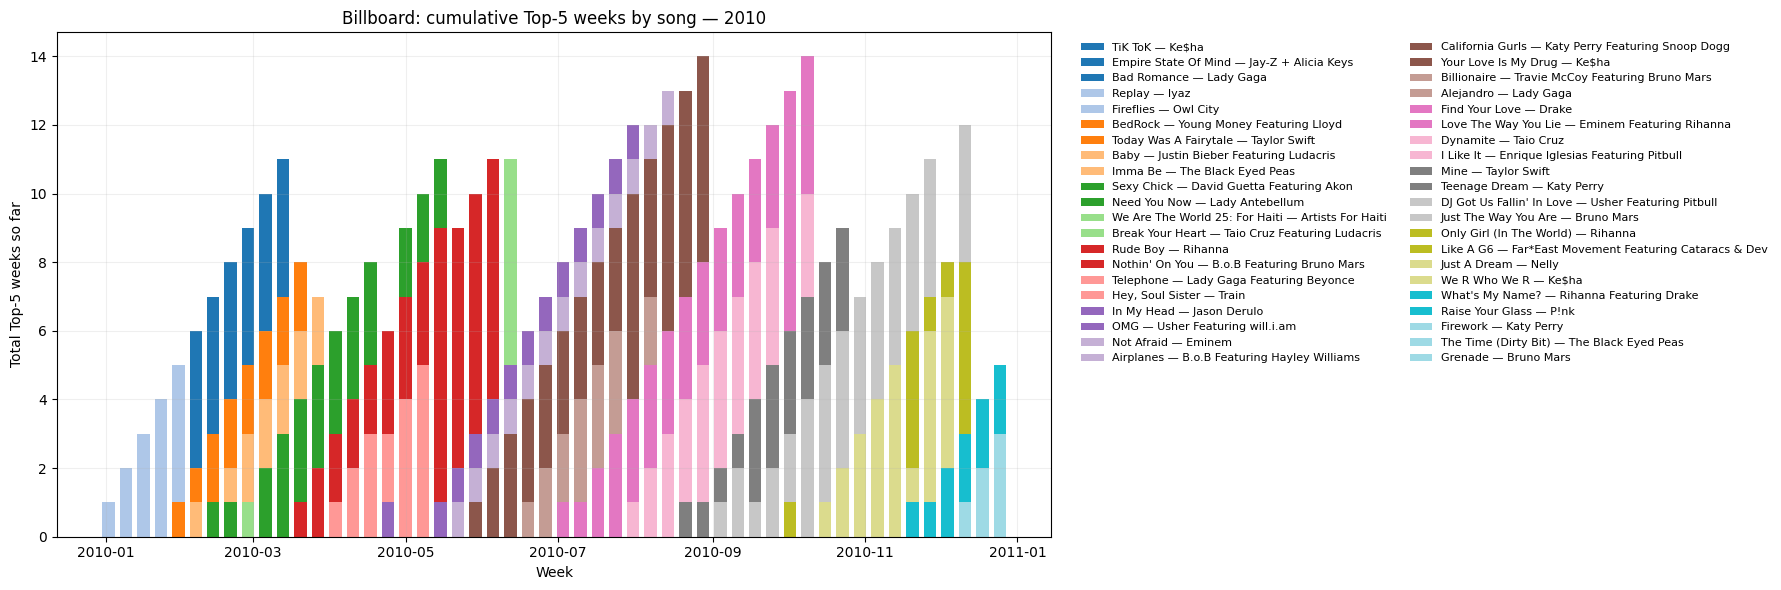

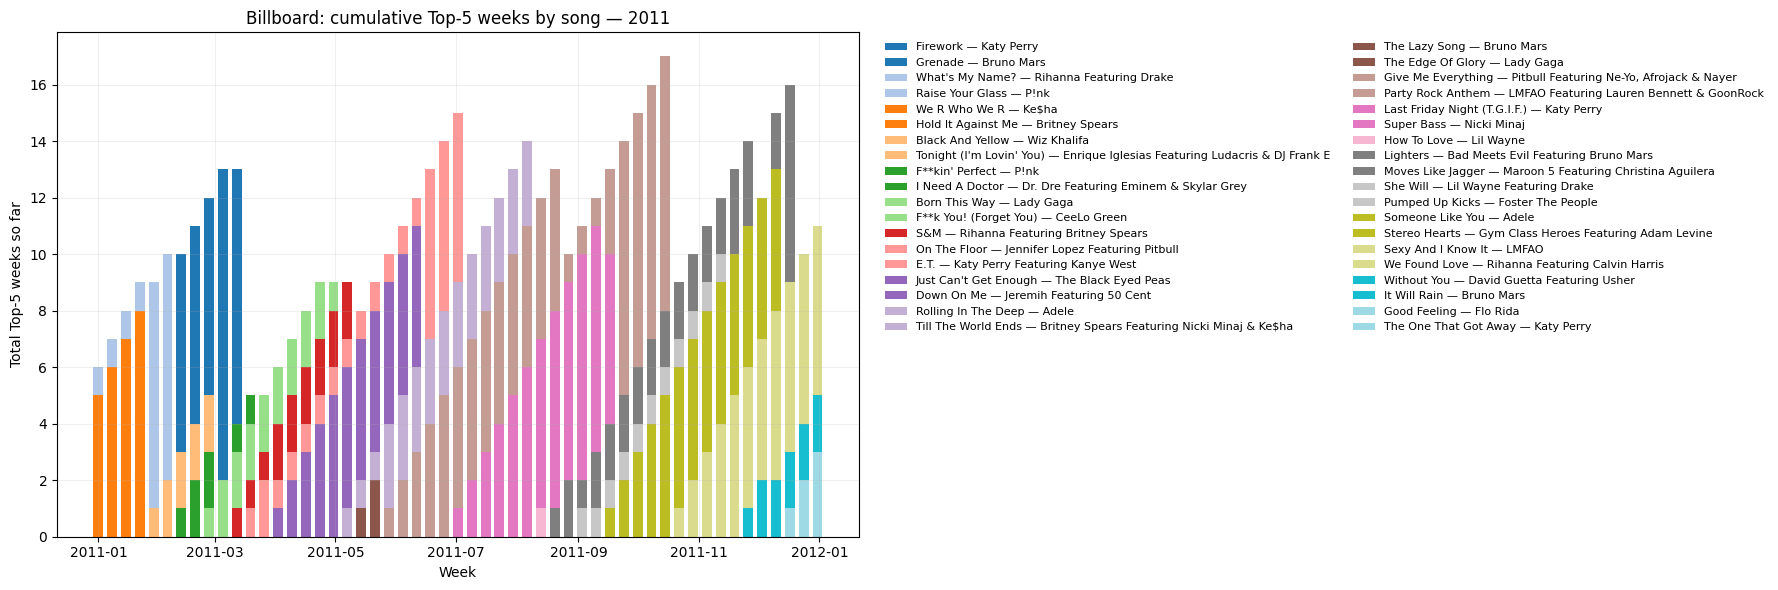

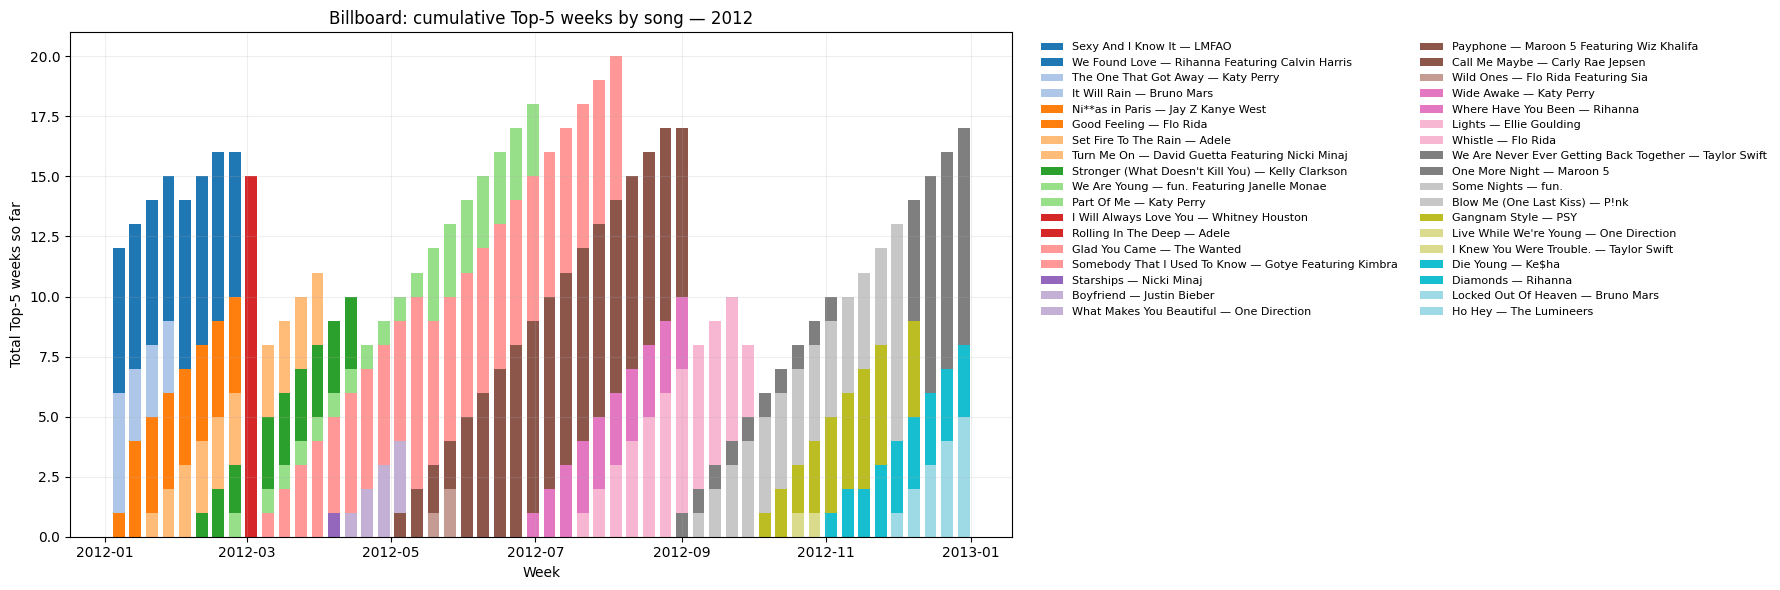

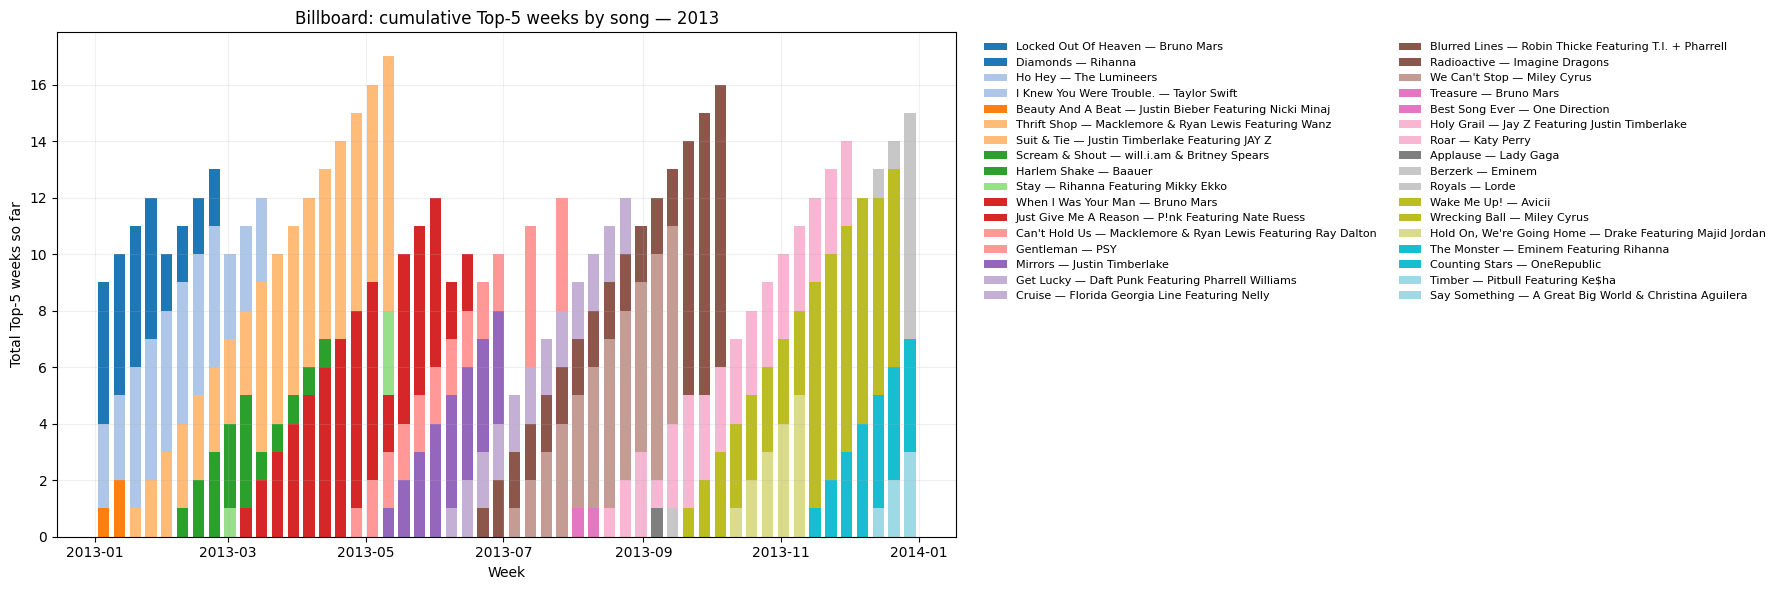

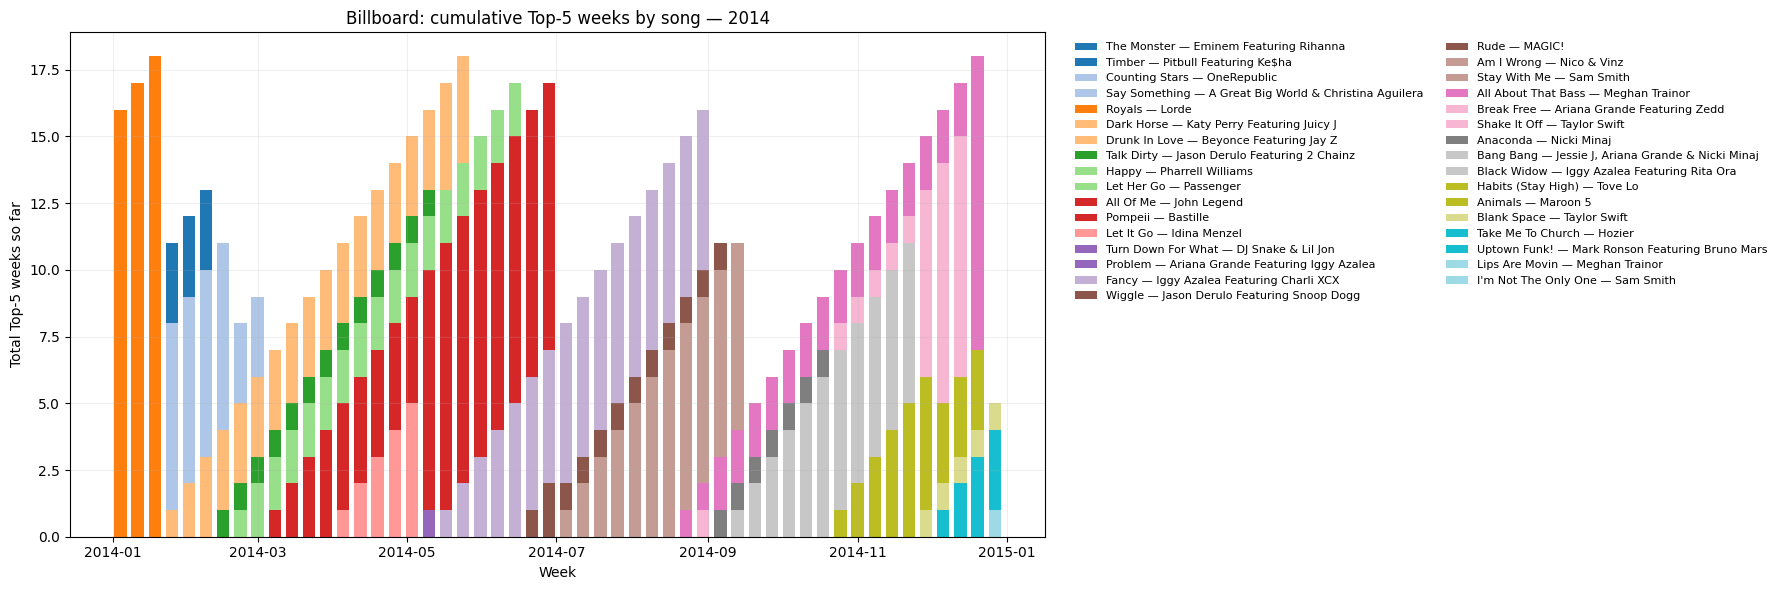

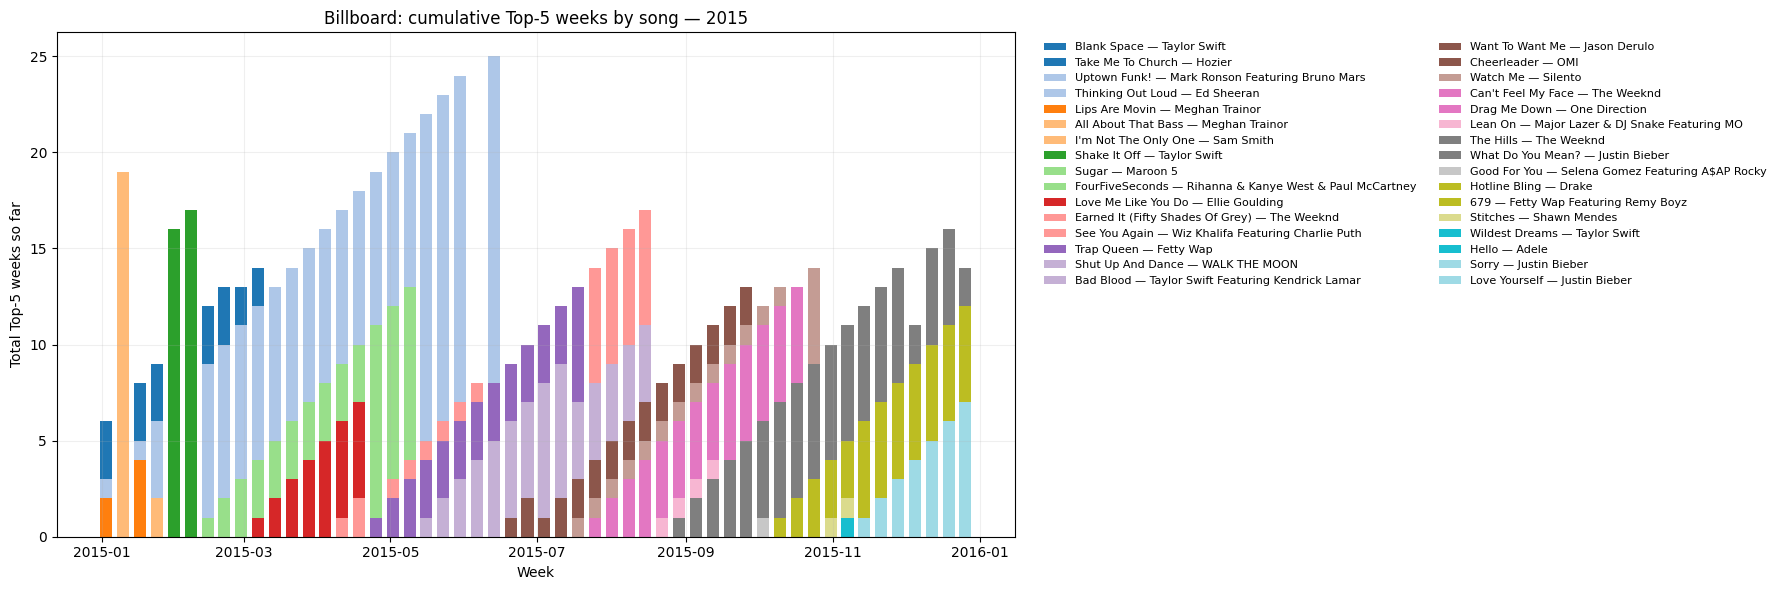

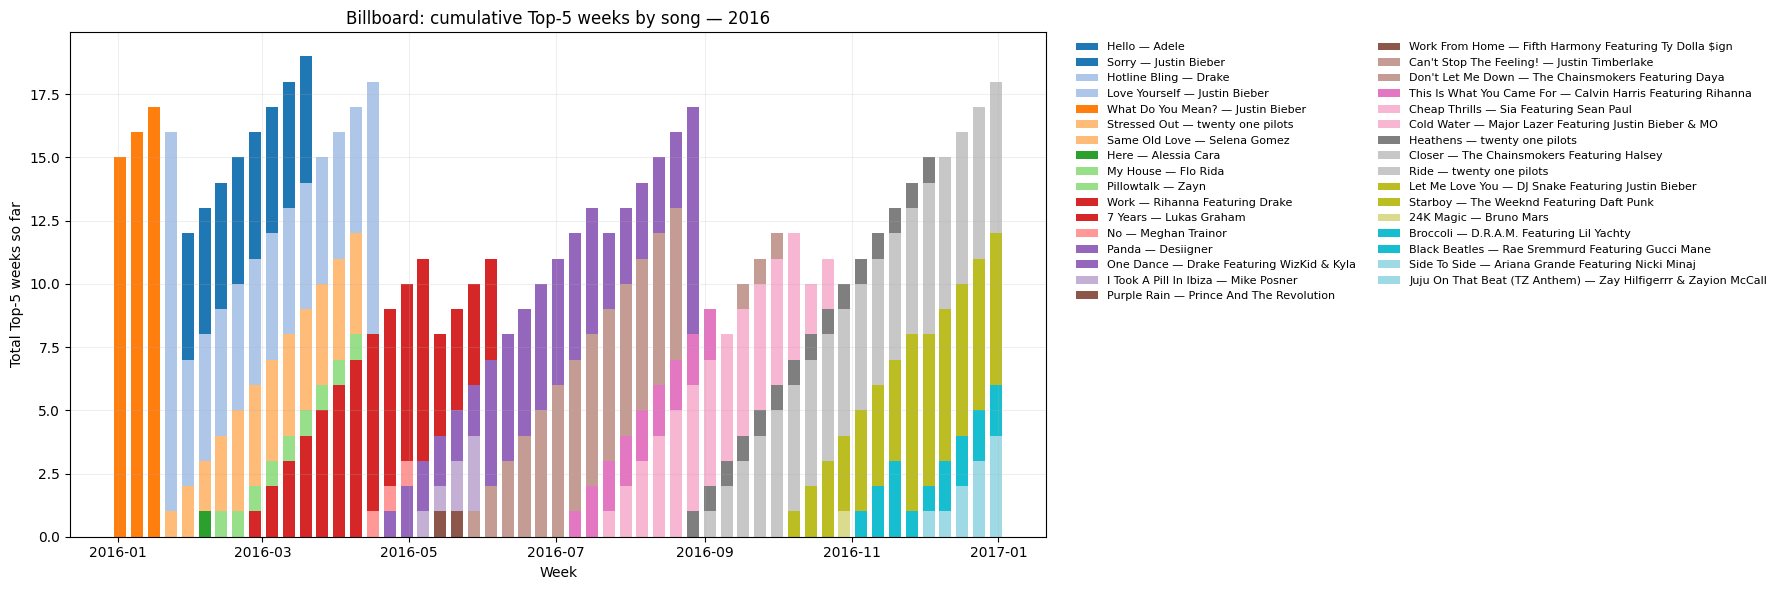

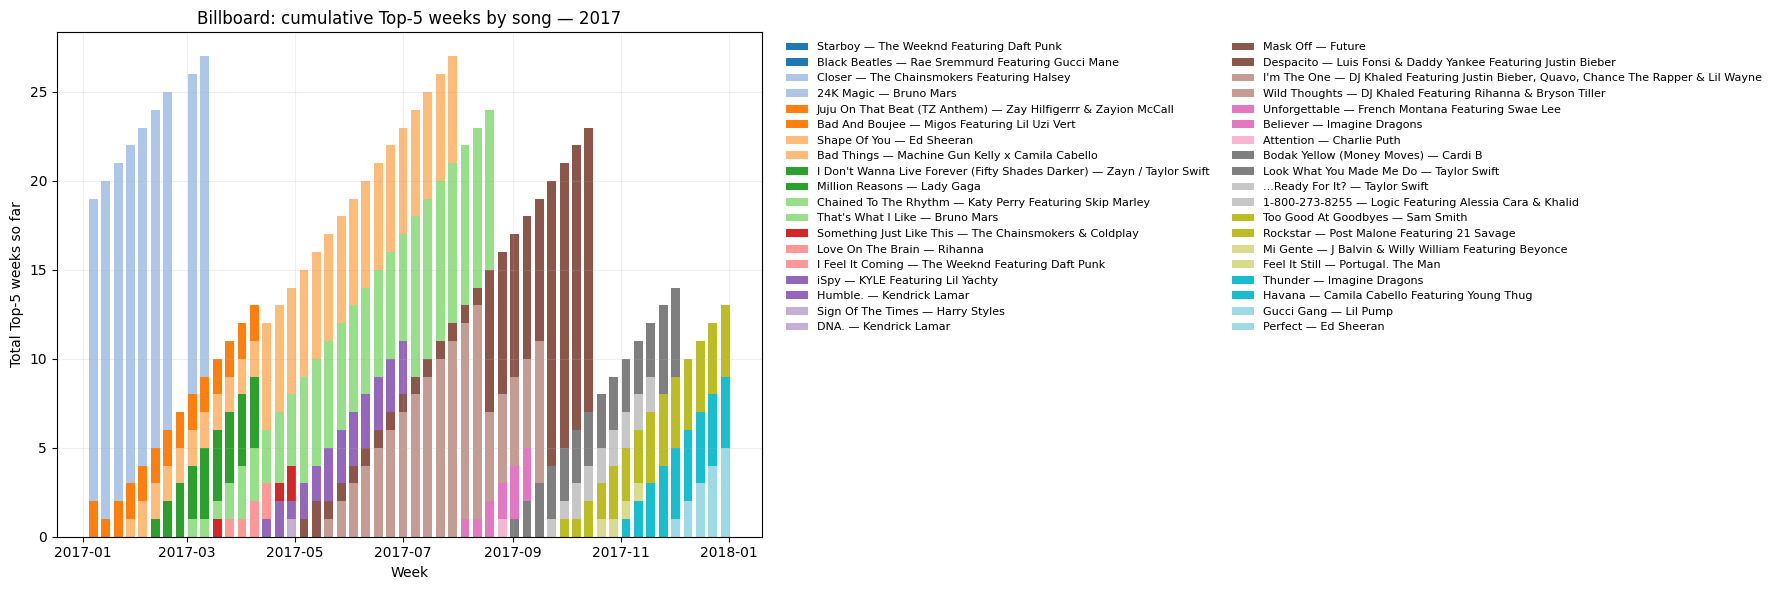

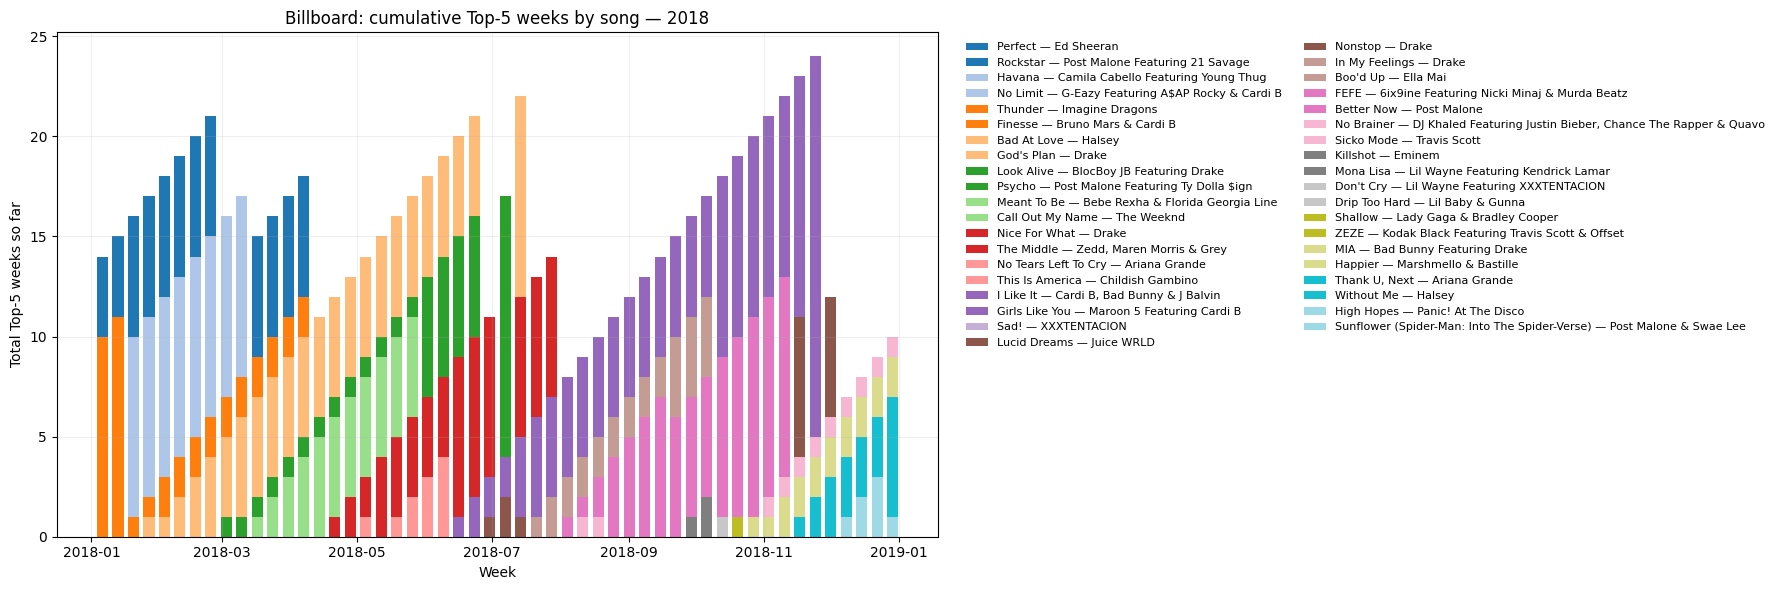

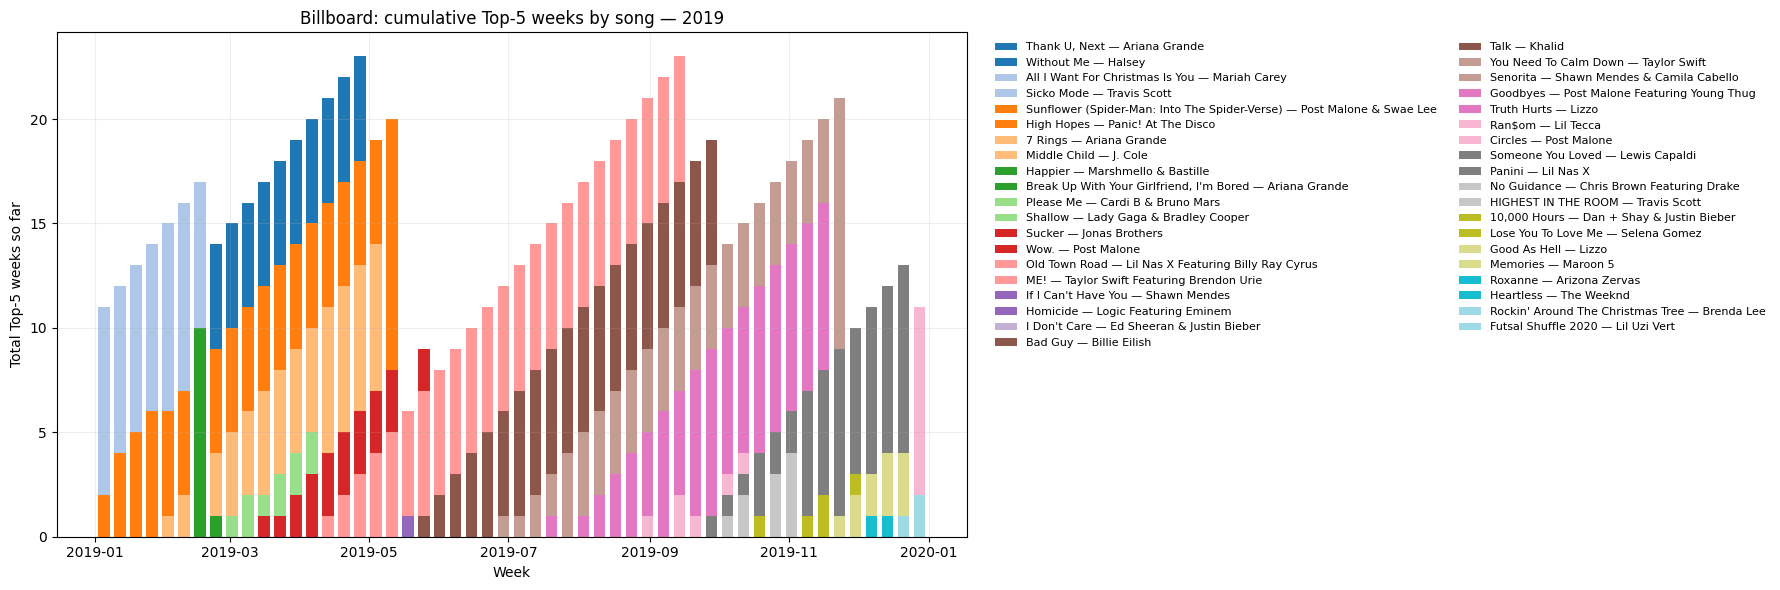

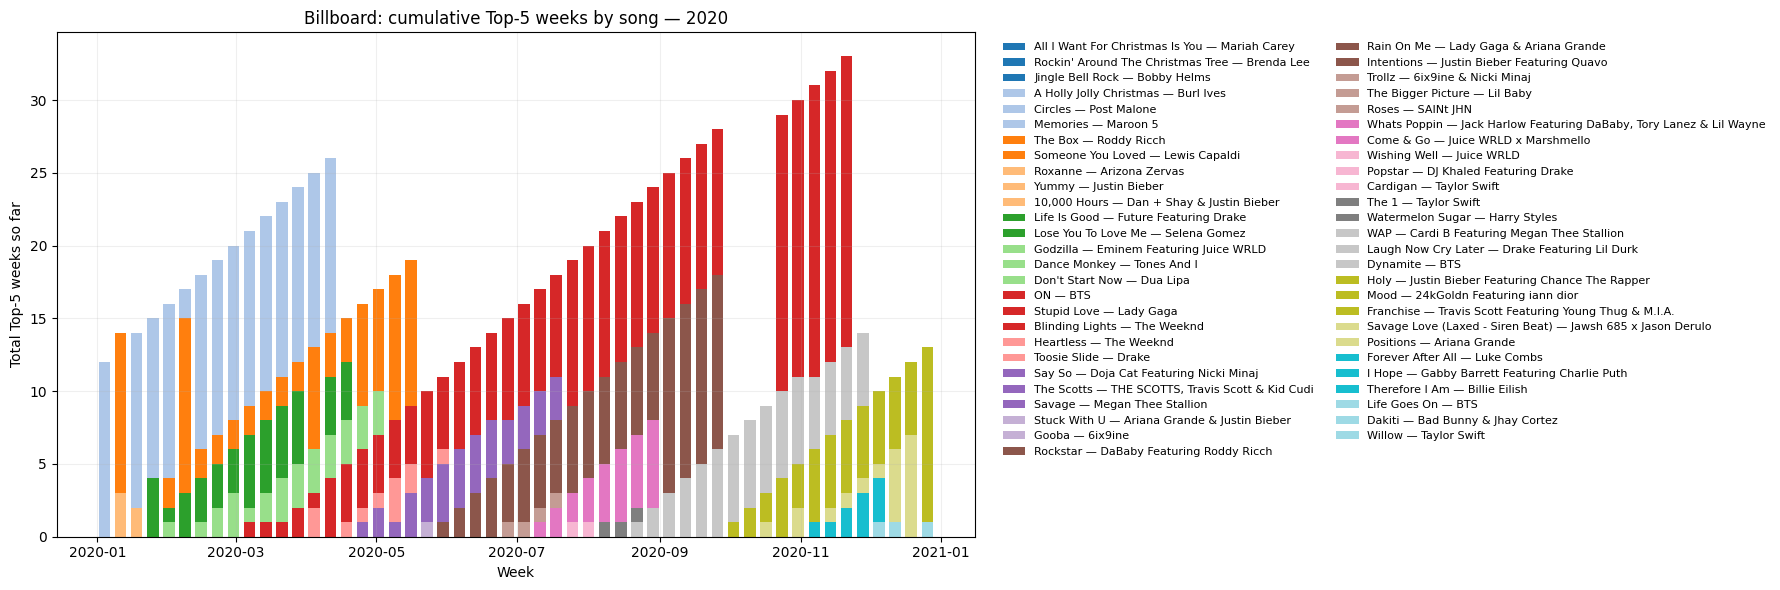

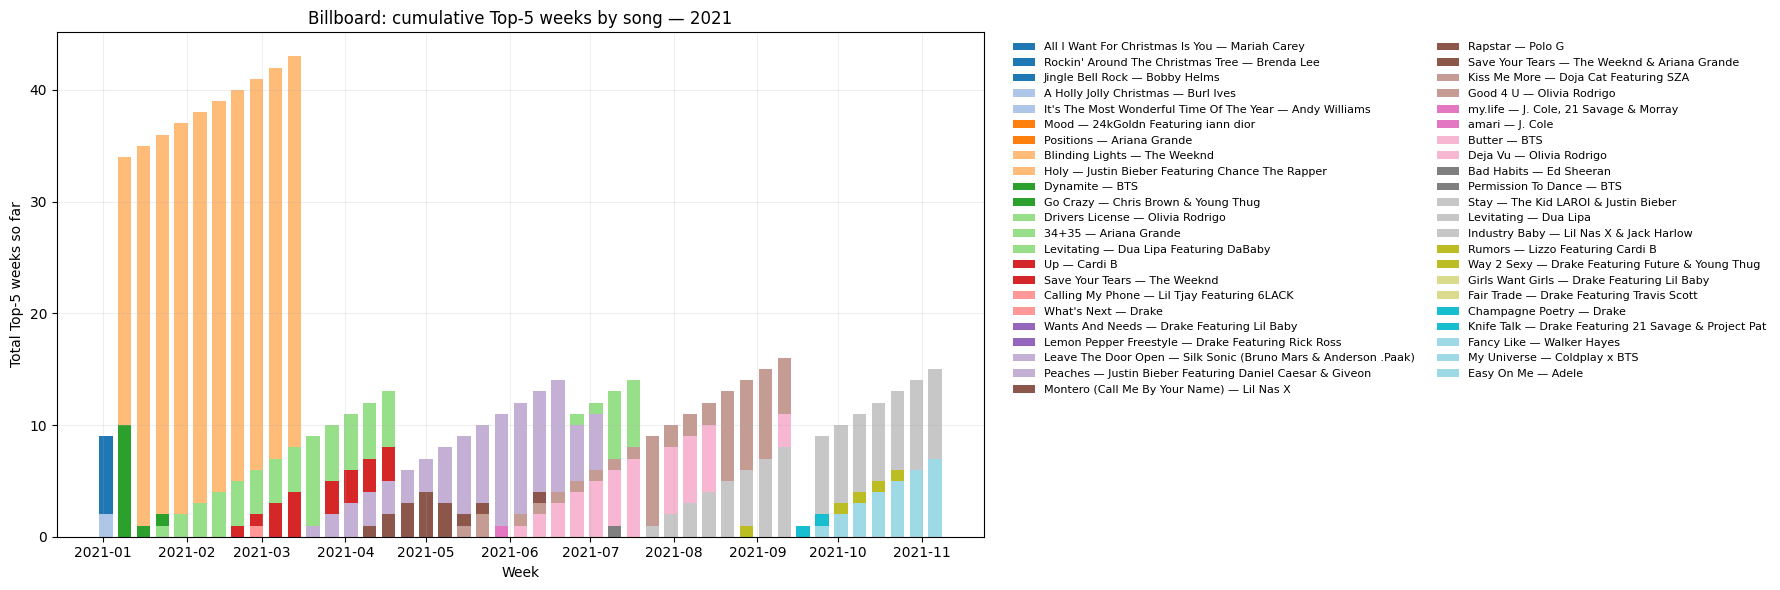

In [9]:

years = sorted(top5["year"].unique())

for y in years:
    dfy = top5[top5["year"] == y].copy()
    if dfy.empty:
        continue

    songs = dfy["song_id"].unique()

    cmap = plt.cm.get_cmap("tab20", max(len(songs), 20))
    color_map = {s: cmap(i % cmap.N) for i, s in enumerate(songs)}

    plt.figure(figsize=(18,6))

    for s in songs:
        sub = dfy[dfy["song_id"] == s]
        plt.bar(
            sub["date"],
            sub["top5_appearances"],
            width=5,
            color=color_map[s],
            label=s
        )

    plt.title(f"Billboard: cumulative Top-5 weeks by song — {y}")
    plt.xlabel("Week")
    plt.ylabel("Total Top-5 weeks so far")
    plt.grid(alpha=0.2)

    plt.legend(
        ncol=2,
        fontsize=8,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()
